In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw/adult.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


age – Age of the individual

workclass – Type of employment (e.g., Private, Self-emp, Government, etc.)

fnlwgt – Final weight, used by the Census Bureau to estimate population statistics

education – Highest education level achieved

education.num – Numerical representation of education level

marital.status – Marital status

occupation – Occupation type

relationship – Relationship status within the household

race – Race of the individual

sex – Gender of the individual

capital.gain – Capital gains reported

capital.loss – Capital losses reported

hours.per.week – Hours worked per week

native.country – Country of origin

income – Income level (<=50K or >50K, classification target)

Tasks to perform
1. Missing Values
2. All Numerical Values
3. Distribution of the Numerical Values
4. Categorical Variables

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.pandas.set_option("display.max_columns", None)

In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### Missing Values

In [5]:
print(df.isnull().mean()*100)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
dtype: float64


In [6]:
df = df.replace("?", np.nan)

In [7]:
features_with_na = [features for features in df.columns if df[features].isnull().sum() > 1]

for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean(), 4), "% missing values")

workclass 0.0564 % missing values
occupation 0.0566 % missing values
native.country 0.0179 % missing values


Since there are many missing values, we need to find the relationship between the missing values and the dependent value

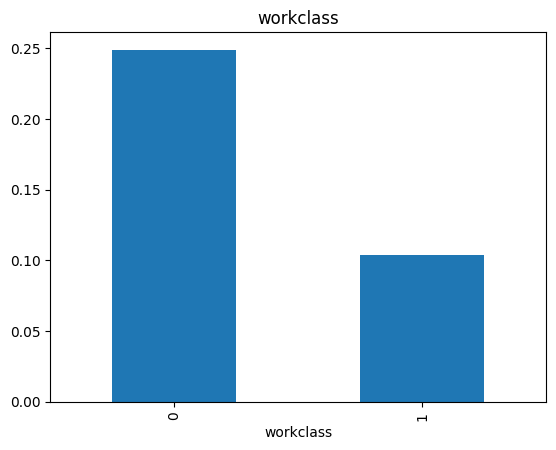

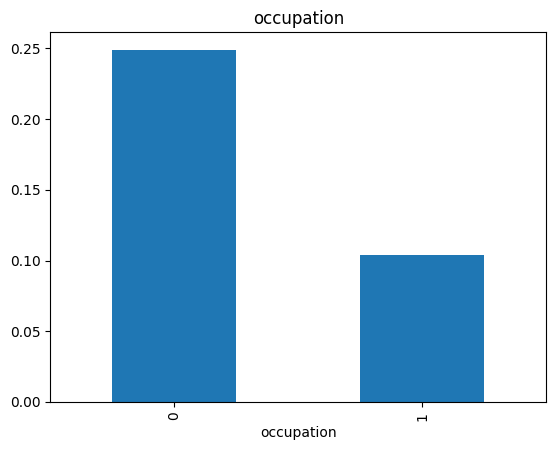

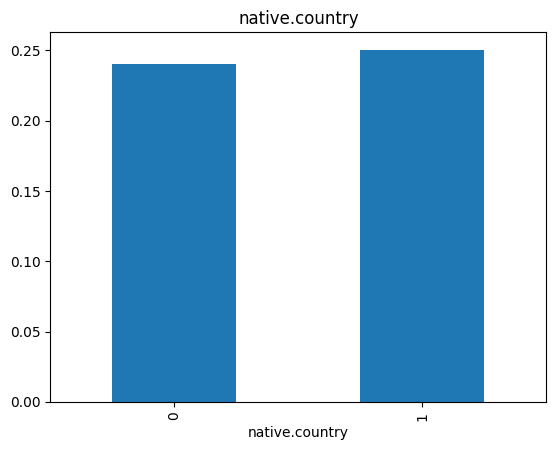

In [8]:
# Diagram to show the relationship between the target variable and the features

# let's map the target variable to 0 and 1 to make it easier to calculate the mean
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

for feature in features_with_na:
    data = df.copy()

    # let's make a variable that indicates 1 if the observation was missing or 0 if it was not missing
    data[feature] = np.where(data[feature].isnull(), 1, 0)

    # let's calcuate the mean of the target variable for the observations with missing values and without missing values for the feature
    data.groupby(feature)['income'].mean().plot.bar()
    plt.title(feature)
    plt.show()

Workclass vs income: 25% of known values earns less than or equal to 50k and remaining 75% earns more than 50k, similarly, 10% of missing values earns more than 50% while remaining 90% of missing values earns less than 50k

occupation vs income: 25% of known values earns less than or equal to 50k and remaining 75% earns more than 50k, similarly, 10% of missing values earns more than 50% while remaining 90% of missing values earns less than 50k

native.country vs income: 24% of known values earns less than or equal to 50k and remaining 76% earns more than 50k, similarly, 25% of missing values earns more than 50k while remaining 75% of missing values earns less than 50k

Here with the relation between the missing values and the dependent variable is clearly visible. So we need replace these nan values with something meaningful which will be addressed in the Feature Engineering section.

#### Numerical Varaibles

In [9]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']

print(numerical_features)

print(len(numerical_features))

['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'income']
7


In [14]:
# Numerical are of two types: discrete and continuous. Discrete features are those that take a finite number of values, while continuous features can take an infinite number of values. Let's identify the discrete and continuous features in our dataset.

discrete_features = [feature for feature in numerical_features if len(df[feature].unique()) < 25 and feature not in ['income']]

print(discrete_features)

['education.num']


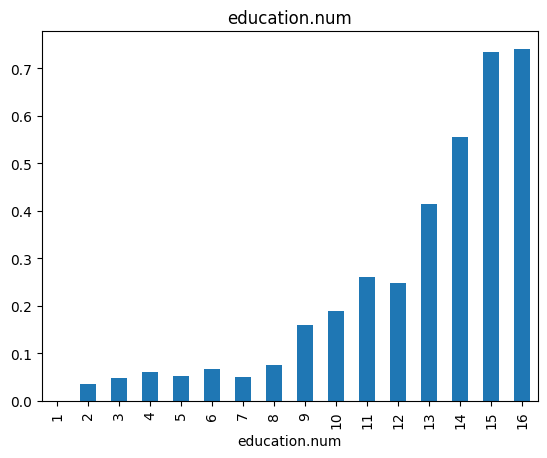

In [15]:
for feature in discrete_features:
    data = df.copy()
    data.groupby(feature)['income'].mean().plot.bar()
    plt.title(feature)
    plt.show()

the graph shows the trend that as the education level of individuals increases so do their percentages of earning above 50k increases.
people with education.num between 1-8 shows that they have close to 10% chance of earning 50k and above while individuals with education.num in 15 and 16 has 70% chance of earning 50k and above.

In [12]:
continuous_features = [feature for feature in numerical_features if feature not in discrete_features]
print(continuous_features)

['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']


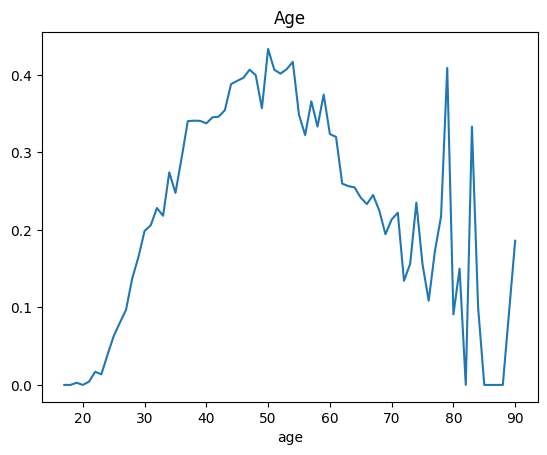

In [21]:
data.groupby(df['age'])['income'].mean().plot.line()
plt.title("Age")
plt.show()

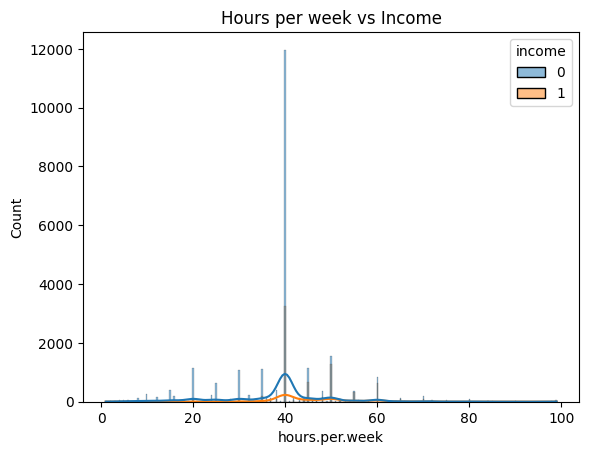

In [18]:
sns.histplot(data=df, x='hours.per.week', hue='income', kde=True)
plt.title('Hours per week vs Income')
plt.show()

Text(0.5, 1.0, 'fnlwgt vs Income')

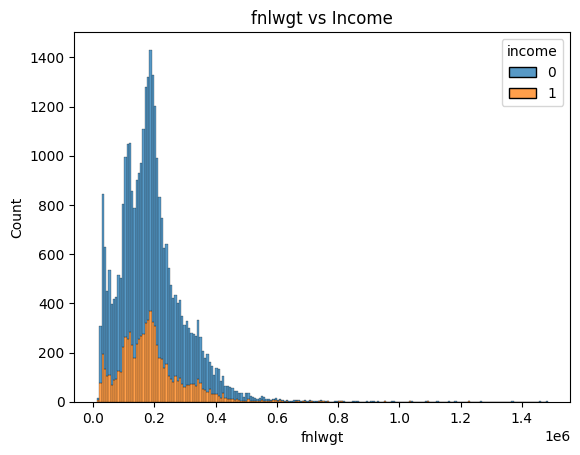

In [19]:
sns.histplot(data=df, x='fnlwgt', hue='income', multiple='stack')
plt.title('fnlwgt vs Income')

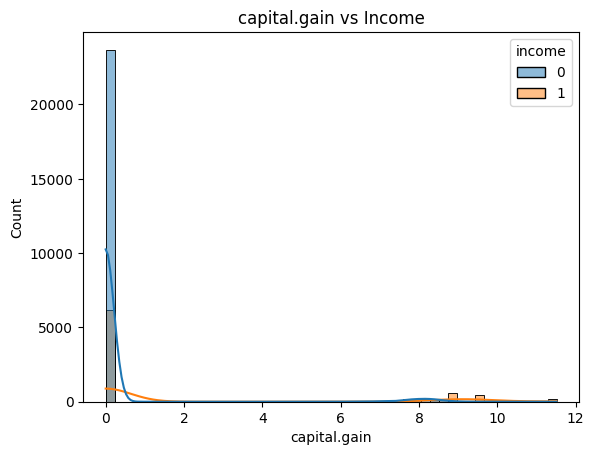

In [24]:
sns.histplot(
    data=df, 
    x=np.log1p(df['capital.gain']), 
    hue='income', 
    bins=50,
    kde=True)
plt.title('capital.gain vs Income')
plt.show()

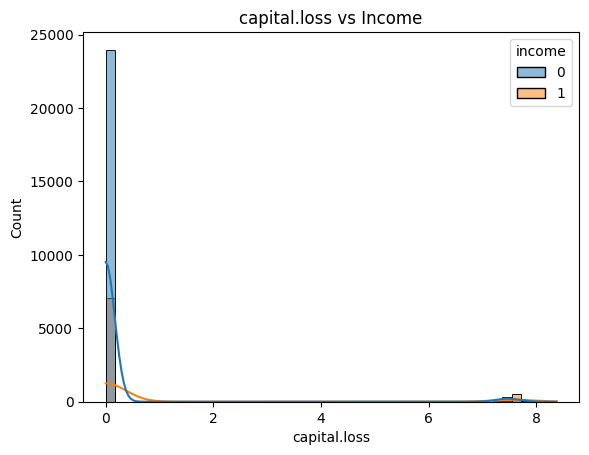

In [25]:
sns.histplot(data=df, x=np.log1p(df['capital.loss']), hue='income', bins=50, kde=True)
plt.title('capital.loss vs Income')
plt.show()

hours.per.week vs income has a strong and intutive relationship. More hours generally equals a higher probability of earning above 50k.

fnlwgt vs income look to have almost zero relationship with income. Whether a person's final weight is 50000 or 500000, their probabitliy of making over 50k is exactly the same

capital.gain vs income: capital.gain is an incredibly strong predictor. If a person has any significant capital gain at all, their probability of earning over 50k approaches nearly 100% 

capital.loss vs income: captial.loss is also a strong predictor. A person needs to earn enough money to invest in the first place to lose money on investment. Low income earners rarely have investment portfolios to declare loss.

#### Catergorical Data

In [28]:
categorical_data = df.select_dtypes(include=['object']).columns

for feature in categorical_data:
    print(f"\nDistribution for {feature}")
    print(df[feature].value_counts(normalize=True)*100)


Distribution for workclass
workclass
Private             73.868186
Self-emp-not-inc     8.270138
Local-gov            6.812042
State-gov            4.224573
Self-emp-inc         3.632221
Federal-gov          3.124491
Without-pay          0.045566
Never-worked         0.022783
Name: proportion, dtype: float64

Distribution for education
education
HS-grad         32.250238
Some-college    22.391818
Bachelors       16.446055
Masters          5.291607
Assoc-voc        4.244341
11th             3.608612
Assoc-acdm       3.276926
10th             2.865391
7th-8th          1.983969
Prof-school      1.768987
9th              1.578576
12th             1.329812
Doctorate        1.268389
5th-6th          1.022696
1st-4th          0.515955
Preschool        0.156629
Name: proportion, dtype: float64

Distribution for marital.status
marital.status
Married-civ-spouse       45.993673
Never-married            32.809189
Divorced                 13.645158
Separated                 3.147938
Widowed       

native.country: Here the United States accounts for 91.22% and Mexico 2.01% while the rest of the country sits at <1%. Problem occurs when we try to one-hot encode this features. Since model might only see 1 or 2 rows of data it can't learn a patter from 2 rows and will overfit so we can group the country with below 1% under a new category called "Other"

Similarly, in Rare Categories(workclass, martial.status, occupation) some features have categories so rare they are practical invisible to the model. like from workclass, Without-pay and Never-worked sit at 0.04 and 0.02 respectively. Same goes for other categories from other features. In order for our model to also account to these categories its best to create a new category called "Other" and group these rare categories in it.

Other features like education, race, sex can be left as is because even though they have minority classes, they still have enough total row presence.

Redundant Feature(education vs education.num): Since both these feature are the same feature one in text and one in number. We can drop the education column entirely before modeling to avoid multi collinearity because education.num caputers the exact order and meaning of educatino perfectly without needing any encoding.

#### Feature Correlation

If two featuers are highly correlated with each other they can confuse linear models and artificially inflate feature importance in tree models.

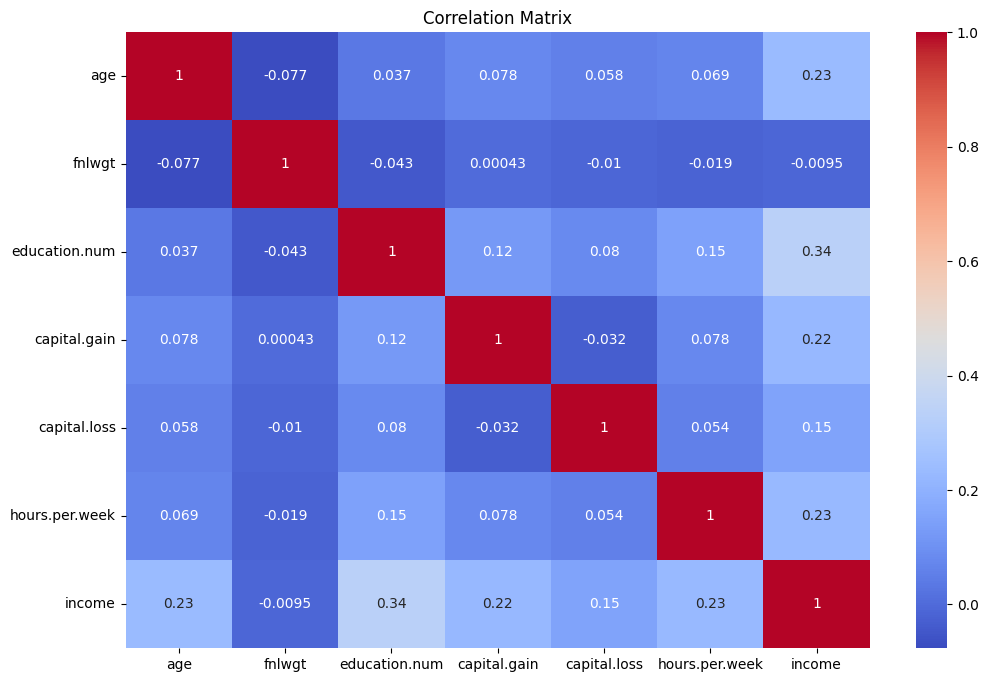

In [33]:
numerical_features = df.select_dtypes(include=['int', 'int64', 'float64'])

corr_matrix = numerical_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Here no 2 features shows high correlation. Almost all the boxes hover between 0.7 and 0.15 meaning features are mathematically independent. They all bring unique information.

looking at the income row, the strongest individual linear coorelation is education.num followed by age and hours.per.week but on the other hand we can see that fnlwgt shows a correlation of -0.0095 this a near zero condition further solidifying the decision to drop this feature entirely

#### Outlier Detection
If features includes outliers they can thow the model off

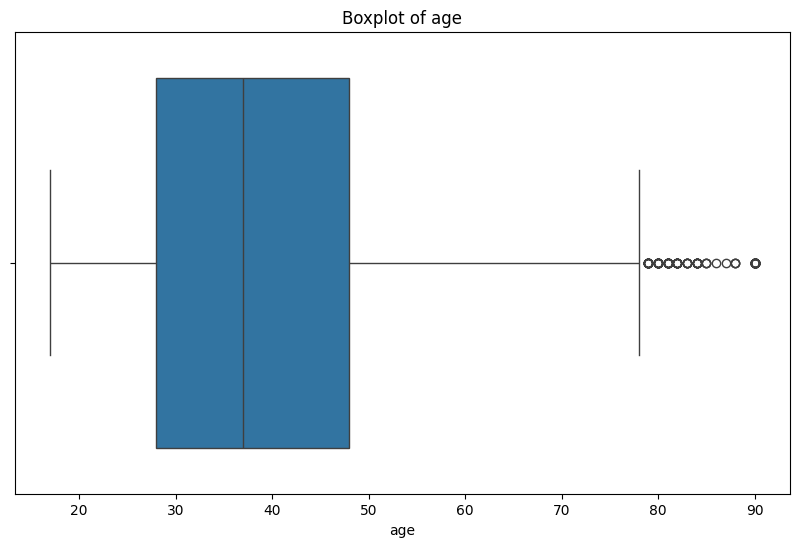

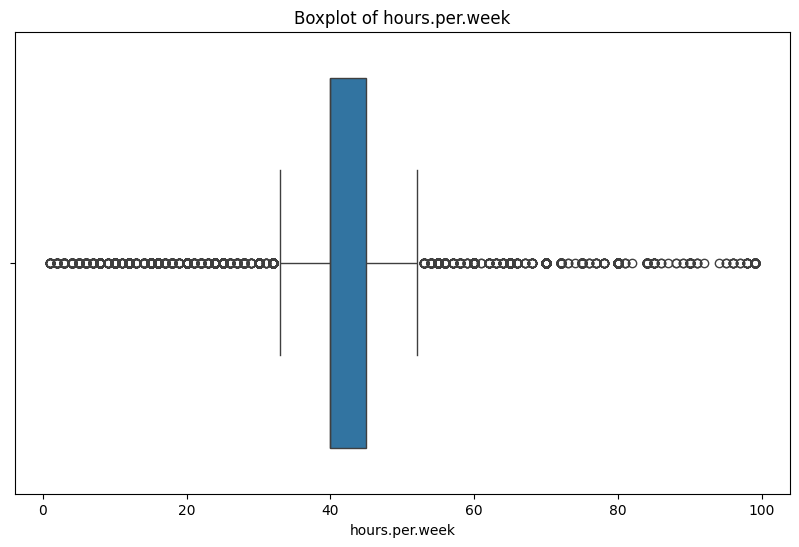

In [34]:
for feature in ['age', 'hours.per.week']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

Based on the Boxplot alone we may have considered to drop those outliner but considering the graph before we see a new side.

age the median age matches with the real world and though the boxplot flagged individual above 78 as outliers based ont the Inter Qutile range rule. But based on the real world we should keep them, individual in this range may have some sort of passive income or retirement funds or have social security benefits.

Boxplot for hours.per.week shows that the median working hours matches the real world at 40-45 and since the data have majority working exactly 40 hours the interquartile rag is compressed tightly between 40 and 45 hours. Due to this narrow central box every working hours beyond the box is treated as outliner but similarly to age we should keep these outliner as it matches the real world. Individual are paid based on how many hours they have work so people working more hours have higher probablility to earn above 50k then those who work less.